In [1]:
# Celda 1 — Título: Imports y configuración
# Descripción: Importa librerías y define constantes usadas en el notebook.
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.gridspec import GridSpecFromSubplotSpec
from src.config import colors, get_birth_values, TIFF_DPI
from matplotlib.patches import Patch
from datetime import datetime


DATASET_PATH = 'data/dataset_mrh_0.9.csv'





In [2]:
# Celda 3 — Título: Opciones de visualización de pandas
# Descripción: Evita truncamientos al mostrar DataFrames en el notebook.

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)



In [3]:
# Celda 4 — Título: Cargar datos
# Descripción: Lee el CSV de datos y crea una copia para emparejamientos.

df = pd.read_csv(DATASET_PATH)
df_for_pairing = df.copy()
print(df.columns.tolist())
# df_daf= df.iloc[:, :3]
# df.head()
df.info()
#df.describe()


['Species', 'Parameter', 'DAF', 'Reference', 'Obs', 'Quote', 'DOI', 'link', 'Cluster', 'Data_curator', 'GA(H+14)']
<class 'pandas.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Species       783 non-null    str    
 1   Parameter     783 non-null    str    
 2   DAF           783 non-null    float64
 3   Reference     783 non-null    str    
 4   Obs           163 non-null    str    
 5   Quote         639 non-null    str    
 6   DOI           780 non-null    str    
 7   link          90 non-null     str    
 8   Cluster       779 non-null    str    
 9   Data_curator  783 non-null    str    
 10  GA(H+14)      58 non-null     float64
dtypes: float64(2), str(9)
memory usage: 67.4 KB


In [4]:
# Celda 5 — Título: Pivot y valores de nacimiento
# Descripción: Crea tabla pivote por parámetro y obtiene valores de nacimiento por especie.

df_pivot = df.pivot_table(index='Parameter', columns='Species', values='DAF', aggfunc='mean').reset_index()
human_birth, mouse_birth, rat_birth = get_birth_values(df_pivot)
df_pivot.sample(10)


Species,Parameter,Human,Mouse,Rat
119,External Capsule AChE reactive,73.5,NaN,19.0
292,Somite 10,23.5,NaN,10.5
117,Excitatory GABAergic response in cortical layer I,126.0,NaN,22.0
138,Gall bladder slightly separated from liver div...,26.0,9.625,NaN
226,Oral membrane perforate,26.0,9.080,NaN
186,Motor neurons expressing Er81 (Spinal cord),77.0,12.000,NaN
281,Secondary bronchi,35.0,12.000,NaN
128,First appearance of noradrenergic cells,35.0,NaN,11.5
188,Myelination begin in the caudate-putamen,231.0,31.000,NaN
208,Npn1-positive cingulate pioneer axons,105.0,NaN,19.0


In [5]:
# Celda 5b — Título: Referencias de los valores de nacimiento
# Descripción: Muestra el DAF de nacimiento de cada especie junto con su referencia bibliográfica y DOI.

birth_rows = df[df['Parameter'] == 'Birth'][['Species', 'DAF', 'Reference', 'DOI']]

print("Birth (DAF) values by species and reference:")
for species, group in birth_rows.groupby('Species'):
    for _, row in group.iterrows():
        print(f"  {species}: DAF={row['DAF']} — {row['Reference']} ({row['DOI']})")
    print(f"  -> Mean used for {species} (get_birth_values): {group['DAF'].mean():.2f}\n")


Birth (DAF) values by species and reference:
  Human: DAF=267.0 — Bergsjø 1990 (https://doi.org/10.3109/00016349009028681)
  Human: DAF=269.4 — Gjerdevik 2026 (https://doi.org/10.1002/uog.70219)
  -> Mean used for Human (get_birth_values): 268.20

  Mouse: DAF=20.0 — Dewar, 1968 (https://doi.org/10.1113/expphysiol.1968.sp001954)
  -> Mean used for Mouse (get_birth_values): 20.00

  Rat: DAF=22.5 — A.M. HAIN 1935 (https://doi.org/10.1113/expphysiol.1936.sp000699)
  -> Mean used for Rat (get_birth_values): 22.50



In [6]:
# Celda 6 — Título: Información rápida del DataFrame
# Descripción: Muestra la forma del DataFrame.

df.shape


(783, 11)

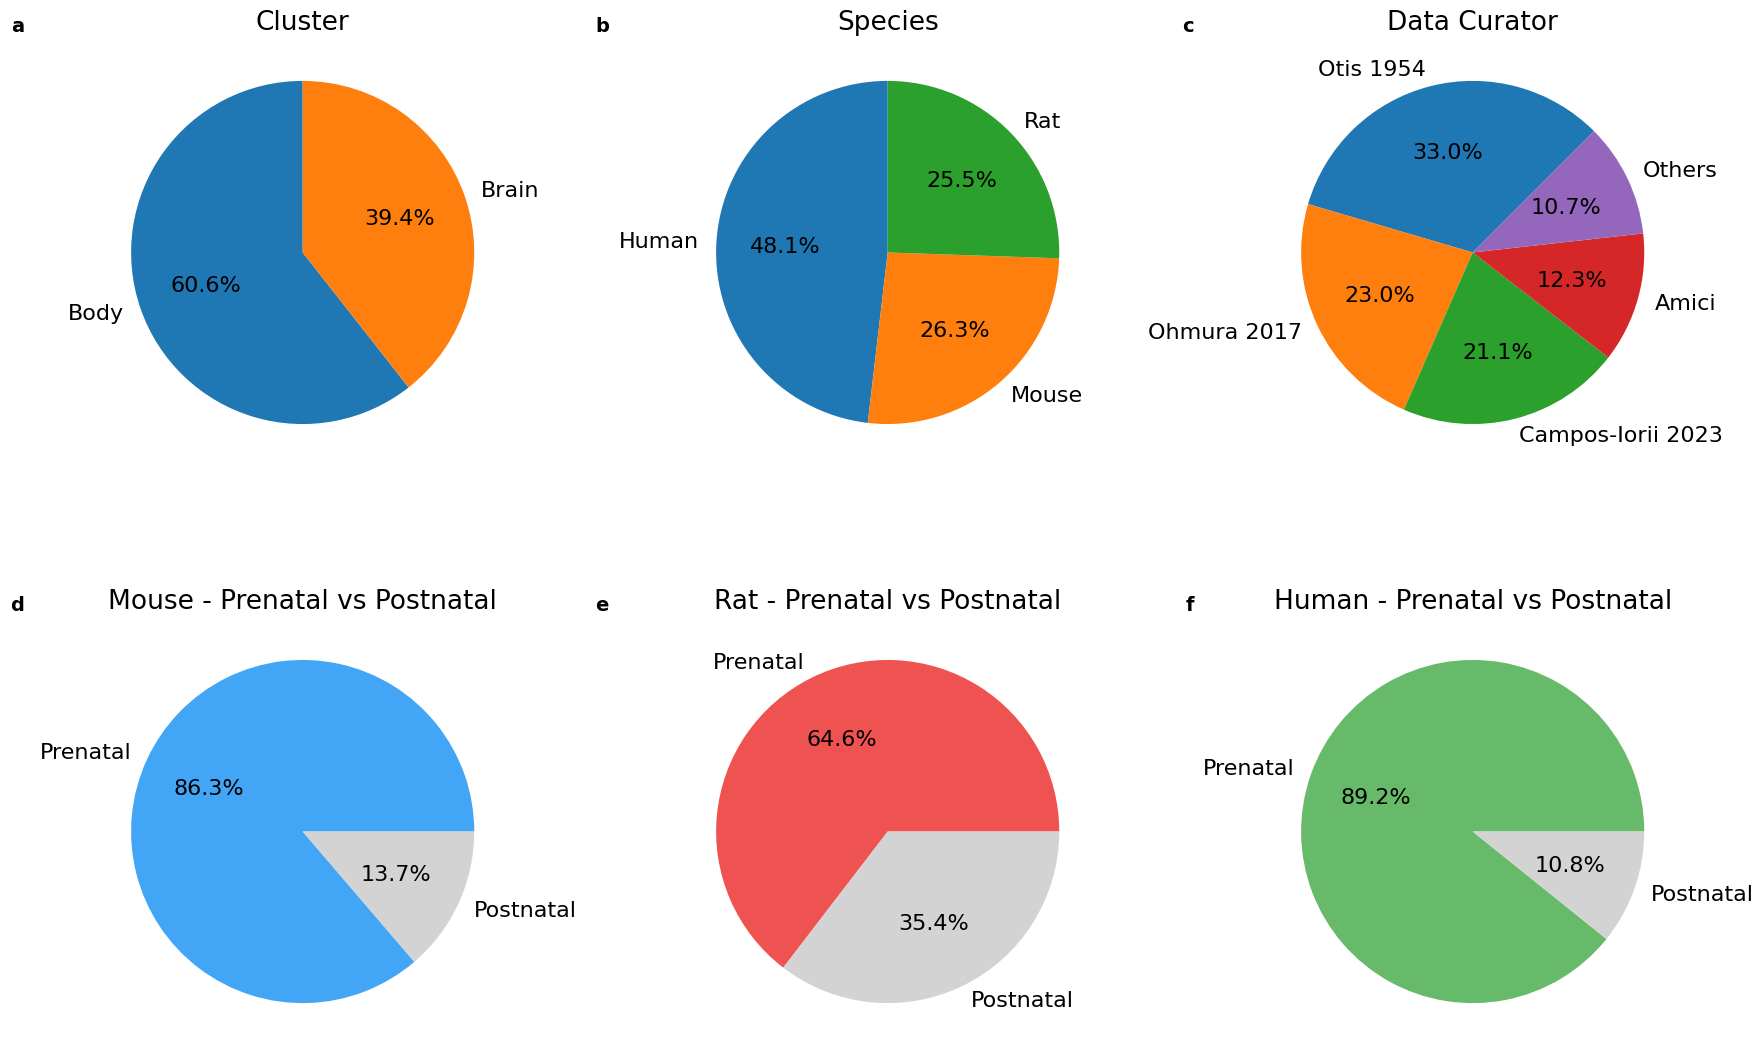

Panel saved as 'figures/panel1.pdf' and 'figures/panel1.tiff'


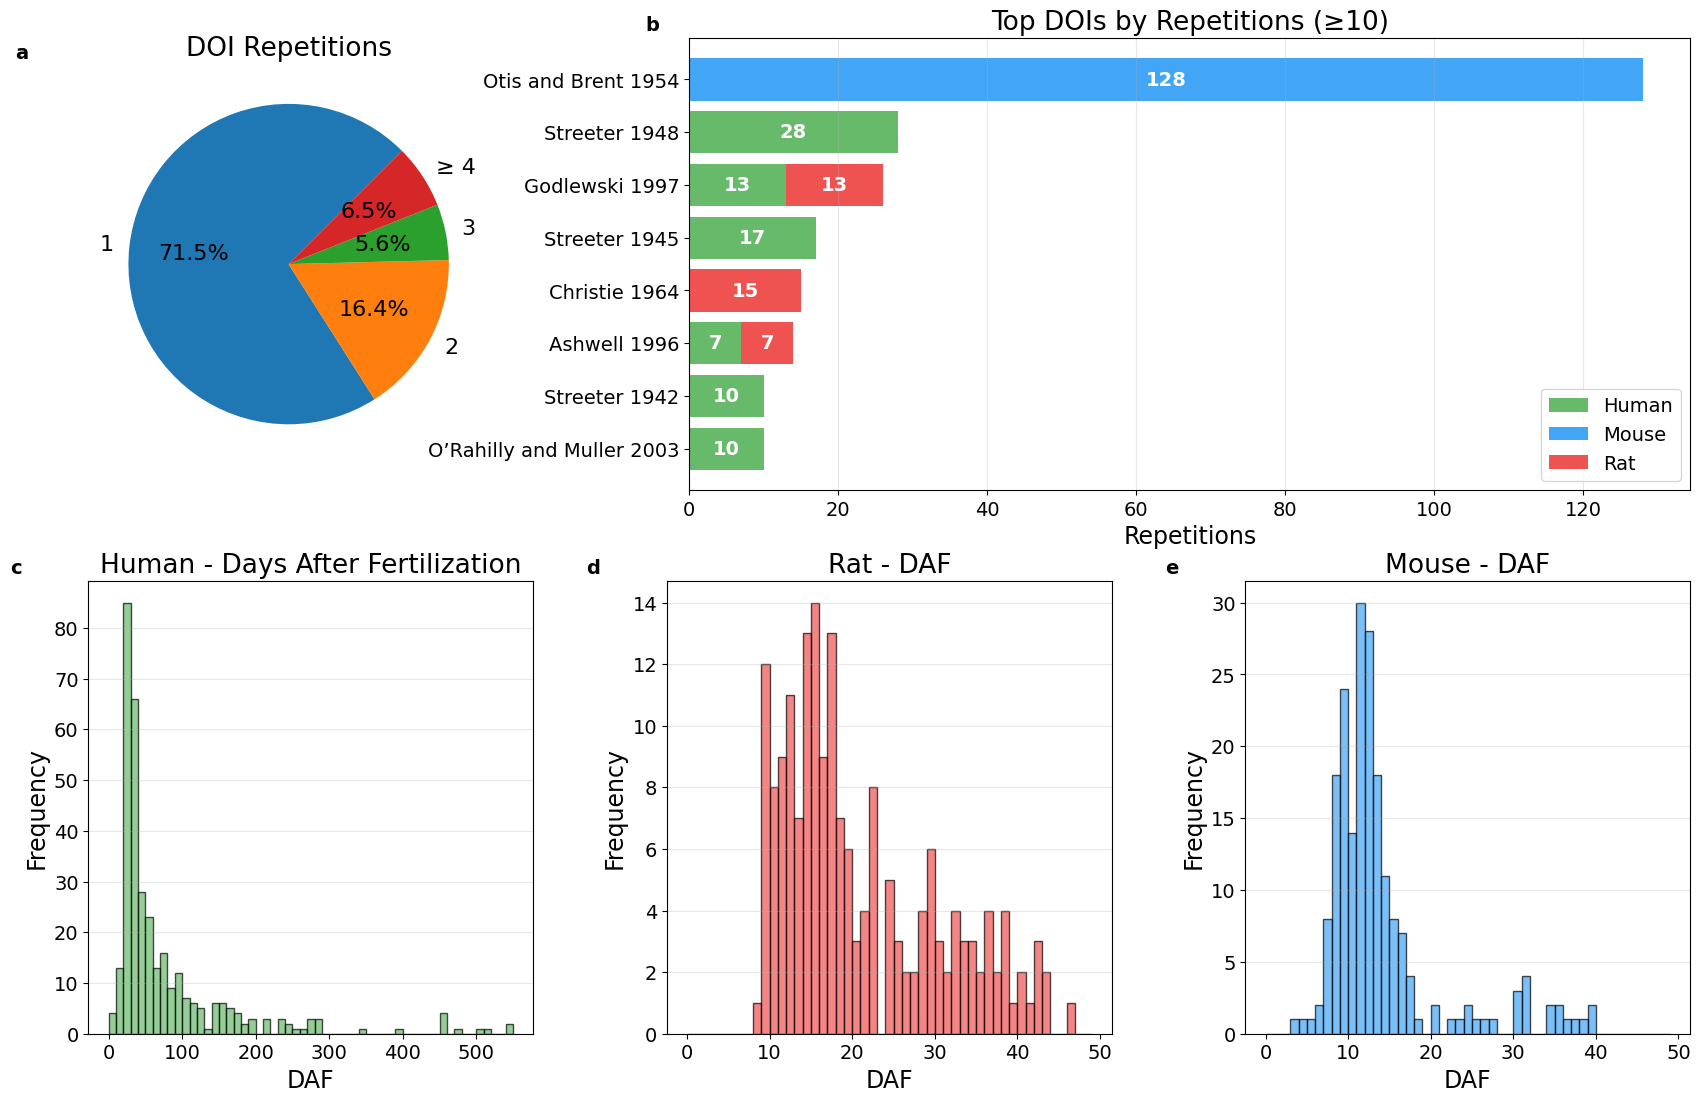

Panel saved as 'figures/panel2.pdf' and 'figures/panel2.tiff'


In [7]:
# Celda 7 — Título: Generación de figuras (Panel 1 y Panel 2)
# Descripción: Prepara datos resumen y genera las figuras principales (pasteles y histogramas), guardando resultados en `figures/`.

# Datos para DOI repetitions
ndoi = df["DOI"].value_counts()
repeticiones = ndoi.value_counts().sort_index()
mask = repeticiones.index >= 4
repeticiones_grouped = repeticiones[~mask].copy()
repeticiones_grouped['≥ 4'] = repeticiones[mask].sum()

# Datos para Top DOIs por referencia
cnt = df.groupby(['DOI', 'Reference']).size().reset_index(name='n')
ref_species = df.groupby('Reference')['Species'].apply(lambda x: x.unique()).reset_index(name='Species_list')
ref_species['Species_count'] = ref_species['Species_list'].apply(len)
cnt = cnt.merge(ref_species[['Reference', 'Species_list', 'Species_count']], on='Reference')
species_per_doi = df.groupby(['DOI', 'Reference'])['Species'].apply(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
)
cnt = cnt.merge(species_per_doi.rename('Primary_Species'), left_on=['DOI', 'Reference'], right_index=True)
top = cnt[cnt['n'] >= 10].sort_values('n', ascending=False).head(15)
tab10 = plt.get_cmap('tab10')
unique_species = top['Primary_Species'].unique()
fallback = {s: tab10(i % 10) for i, s in enumerate(unique_species)}

# ================================================================
# Panel 1 - Part 1: first 6 pie charts
# ================================================================
fig1, axs1 = plt.subplots(2, 3, figsize=(18, 12))
plt.subplots_adjust(left=0.06, right=0.97, top=0.92, bottom=0.08, wspace=0.25, hspace=0.35)

# 1. Cluster
ax1 = axs1[0, 0]
counts_cluster = df["Cluster"].value_counts()
ax1.pie(counts_cluster, labels=counts_cluster.index, autopct="%1.1f%%", startangle=90, textprops={'fontsize': 16})
ax1.set_title("Cluster", fontsize=19)
ax1.text(-0.15, 1.05, 'a', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 2. Species
ax2 = axs1[0, 1]
counts_species = df["Species"].value_counts()
ax2.pie(counts_species, labels=counts_species.index, autopct="%1.1f%%", startangle=90, textprops={'fontsize': 16})
ax2.set_title("Species", fontsize=19)
ax2.text(-0.15, 1.05, 'b', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 3. Data Curator (top, rest as "Others")
ax3 = axs1[0, 2]
counts_curator = df["Data_curator"].value_counts()
top_curators = counts_curator.head(4)
other_curators = counts_curator.iloc[4:].sum()
if other_curators > 0:
    top_curators = pd.concat([top_curators, pd.Series([other_curators], index=['Others'])])
ax3.pie(top_curators, labels=top_curators.index, autopct="%1.1f%%", startangle=45, textprops={'fontsize': 16})
ax3.set_title("Data Curator", fontsize=19)
ax3.text(-0.15, 1.05, 'c', transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 4. Mouse Prenatal/Postnatal
ax4 = axs1[1, 0]
mouse_data = df_pivot[["Parameter", "Mouse"]].dropna()
prenatal_mouse = (mouse_data["Mouse"] < mouse_birth).sum()
postnatal_mouse = (mouse_data["Mouse"] >= mouse_birth).sum()
ax4.pie([prenatal_mouse, postnatal_mouse], labels=["Prenatal", "Postnatal"],
        autopct="%1.1f%%", colors=[colors["Mouse"], "lightgray"], textprops={'fontsize': 16})
ax4.set_title("Mouse - Prenatal vs Postnatal", fontsize=19)
ax4.text(-0.15, 1.05, 'd', transform=ax4.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 5. Rat Prenatal/Postnatal
ax5 = axs1[1, 1]
rat_data = df_pivot[["Parameter", "Rat"]].dropna()
prenatal_rat = (rat_data["Rat"] < rat_birth).sum()
postnatal_rat = (rat_data["Rat"] >= rat_birth).sum()
ax5.pie([prenatal_rat, postnatal_rat], labels=["Prenatal", "Postnatal"],
        autopct="%1.1f%%", colors=[colors["Rat"], "lightgray"], textprops={'fontsize': 16})
ax5.set_title("Rat - Prenatal vs Postnatal", fontsize=19)
ax5.text(-0.15, 1.05, 'e', transform=ax5.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 6. Human Prenatal/Postnatal
ax6 = axs1[1, 2]
human_data = df_pivot[["Parameter", "Human"]].dropna()
prenatal_human = (human_data["Human"] < human_birth).sum()
postnatal_human = (human_data["Human"] >= human_birth).sum()
ax6.pie([prenatal_human, postnatal_human], labels=["Prenatal", "Postnatal"],
        autopct="%1.1f%%", colors=[colors["Human"], "lightgray"], textprops={'fontsize': 16})
ax6.set_title("Human - Prenatal vs Postnatal", fontsize=19)
ax6.text(-0.15, 1.05, 'f', transform=ax6.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# Evita problemas de fuentes en revistas/editoriales
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.savefig('figures/panel1.pdf', bbox_inches='tight')
plt.savefig('figures/panel1.tiff', dpi=TIFF_DPI, bbox_inches='tight')
plt.show()
print("Panel saved as 'figures/panel1.pdf' and 'figures/panel1.tiff'")

# ================================================================
# Panel 1 - Part 2: remaining charts with nested GridSpec
# ================================================================
fig2 = plt.figure(figsize=(18, 12))
plt.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.09)

# Gridspec principal: 2 filas (arriba más grande que abajo)
gs_main = fig2.add_gridspec(2, 1)

# Subgridspec para bloque superior (2 filas, 3 columnas)
gs_top = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_main[0], hspace=0.3, wspace=0.50)

# Subgridspec para bloque inferior (1 fila, 3 columnas)
gs_bottom = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_main[1], wspace=0.30)

# 7. DOI Repetitions
ax7 = fig2.add_subplot(gs_top[0, 0])
ax7.pie(repeticiones_grouped,
        labels=[f'{k}' if k != '≥ 4' else k for k in repeticiones_grouped.index],
        autopct="%1.1f%%", startangle=45, textprops={'fontsize': 16})
ax7.set_title("DOI Repetitions", fontsize=19)
ax7.text(-0.15, 1.05, 'a', transform=ax7.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 8. Top DOIs por Referencia
ax8 = fig2.add_subplot(gs_top[0:2, 1:3])
top_panel = top.head(12)
y_pos = 0
y_labels = []

for idx, row in top_panel.iterrows():
    ref = row['Reference']
    n = row['n']
    species_list = row['Species_list']
    y_labels.append(ref)

    if len(species_list) == 1:
        color = colors.get(species_list[0], fallback.get(species_list[0], '#808080'))
        ax8.barh(y_pos, n, color=color)
        ax8.text(n / 2, y_pos, str(int(n)), ha='center', va='center',
                 color='white', fontweight='bold', fontsize=14)
    else:
        half_width = n / len(species_list)
        x_acc = 0
        for species in species_list:
            color = colors.get(species, fallback.get(species, '#808080'))
            ax8.barh(y_pos, half_width, left=x_acc, color=color)
            ax8.text(x_acc + half_width / 2, y_pos, f'{int(half_width)}',
                     ha='center', va='center', color='white', fontweight='bold', fontsize=14)
            x_acc += half_width

    y_pos += 1

ax8.set_yticks(range(len(top_panel)))
ax8.set_yticklabels(y_labels, fontsize=14)
ax8.invert_yaxis()
ax8.set_xlabel('Repetitions', fontsize=17)#, fontweight='bold'
ax8.set_title("Top DOIs by Repetitions (≥10)", fontsize=19)
ax8.text(-0.03, 1.05, 'b', transform=ax8.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax8.grid(axis='x', alpha=0.3)
ax8.tick_params(axis='x', labelsize=14)

legend_elements = [Patch(facecolor=colors.get(s, fallback.get(s, '#808080')), label=f'{s}')
                   for s in sorted(top_panel['Primary_Species'].unique())]
ax8.legend(handles=legend_elements, loc='lower right', fontsize=14)#, title='Species'

# 9. Human histogram
ax9 = fig2.add_subplot(gs_bottom[0, 0])
ax9.hist(df_pivot["Human"].dropna(), color=colors["Human"], bins=range(0, 560, 10), edgecolor='black', alpha=0.7)
ax9.set_title("Human - Days After Fertilization", fontsize=19)
ax9.set_xlabel("DAF", fontsize=17)
ax9.set_ylabel("Frequency", fontsize=17)
ax9.tick_params(axis='both', labelsize=14)
ax9.grid(axis='y', alpha=0.3)
ax9.text(-0.15, 1.05, 'c', transform=ax9.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 10. Rat histogram
ax10 = fig2.add_subplot(gs_bottom[0, 1])
ax10.hist(df_pivot["Rat"].dropna(), color=colors["Rat"], bins=range(0, 50, 1), edgecolor='black', alpha=0.7)
ax10.set_title("Rat - DAF", fontsize=19)
ax10.set_xlabel("DAF", fontsize=17)
ax10.set_ylabel("Frequency", fontsize=17)
ax10.tick_params(axis='both', labelsize=14)
ax10.grid(axis='y', alpha=0.3)
ax10.text(-0.15, 1.05, 'd', transform=ax10.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# 11. Mouse histogram
ax11 = fig2.add_subplot(gs_bottom[0, 2])
ax11.hist(df_pivot["Mouse"].dropna(), color=colors["Mouse"], bins=range(0, 50, 1), edgecolor='black', alpha=0.7)
ax11.set_title("Mouse - DAF", fontsize=19)
ax11.set_xlabel("DAF", fontsize=17)
ax11.set_ylabel("Frequency", fontsize=17)
ax11.tick_params(axis='both', labelsize=14)
ax11.grid(axis='y', alpha=0.3)
ax11.text(-0.15, 1.05, 'e', transform=ax11.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

plt.savefig('figures/panel2.pdf', bbox_inches='tight')
plt.savefig('figures/panel2.tiff', dpi=TIFF_DPI, bbox_inches='tight')
plt.show()
print("Panel saved as 'figures/panel2.pdf' and 'figures/panel2.tiff'")


In [8]:
# Celda 8 — Título: Resumen de disponibilidad y logging
# Descripción: Calcula disponibilidad por especie, perfiles de overlap, parámetros exclusivos y actualiza el log de resultados.

# Consolidated: compute pivot/overlap/exclusive, then write log
df_pivot = df_for_pairing.pivot_table(
    index='Parameter',
    columns='Species',
    values='DAF',
    aggfunc='mean',
).reset_index()
for col in ['Human', 'Rat', 'Mouse']:
    if col not in df_pivot.columns:
        df_pivot[col] = np.nan
total_parameters = len(df_pivot)
availability = df_pivot[['Human', 'Rat', 'Mouse']].notna()
pair_summary = pd.DataFrame({
    'Pairing': ['Human-Rat', 'Human-Mouse', 'Rat-Mouse', 'Human-Rat-Mouse'],
    'Paired parameters (n)': [
        int((availability['Human'] & availability['Rat']).sum()),
        int((availability['Human'] & availability['Mouse']).sum()),
        int((availability['Rat'] & availability['Mouse']).sum()),
        int((availability['Human'] & availability['Rat'] & availability['Mouse']).sum()),
    ],
})
pair_summary['Paired parameters (%)'] = (100 * pair_summary['Paired parameters (n)'] / total_parameters).round(2)
print(f"Total parameters in pivot: {total_parameters}")
display(pair_summary)
overlap_profile = (
    availability.astype(int).astype(str)
    .agg(''.join, axis=1)
    .value_counts()
    .rename_axis('HumanRatMouse')
    .reset_index(name='n')
 )
code_map = {
    '000': 'No species available',
    '100': 'Only Human',
    '010': 'Only Rat',
    '001': 'Only Mouse',
    '110': 'Human-Rat only',
    '101': 'Human-Mouse only',
    '011': 'Rat-Mouse only',
    '111': 'Human-Rat-Mouse',
}
overlap_profile['Category'] = overlap_profile['HumanRatMouse'].map(code_map).fillna('Other')
overlap_profile['%'] = (100 * overlap_profile['n'] / total_parameters).round(2)
print("\nDetailed overlap profile:")
display(overlap_profile[['Category', 'n', '%']].sort_values('n', ascending=False).reset_index(drop=True))
only_human_params = df_pivot.loc[availability['Human'] & ~availability['Rat'] & ~availability['Mouse'], 'Parameter'].sort_values().tolist()
only_rat_params = df_pivot.loc[~availability['Human'] & availability['Rat'] & ~availability['Mouse'], 'Parameter'].sort_values().tolist()
only_mouse_params = df_pivot.loc[~availability['Human'] & ~availability['Rat'] & availability['Mouse'], 'Parameter'].sort_values().tolist()
exclusive_params = pd.DataFrame({
    'Only Human': pd.Series(only_human_params),
    'Only Rat': pd.Series(only_rat_params),
    'Only Mouse': pd.Series(only_mouse_params),
})
print("\nParameters exclusive to one species:")
print(f"Only Human: {len(only_human_params)}")
print(f"Only Rat: {len(only_rat_params)}")
print(f"Only Mouse: {len(only_mouse_params)}")
print("Only Mouse params:", only_mouse_params)
display(exclusive_params)

# Continue with logging
NOTEBOOK_KEY = "panel1_0.1"
# Duplicate rows by (Parameter, Species)
dup_mask = df.duplicated(subset=['Parameter', 'Species'], keep=False)
n_dup_param_species_rows = int(dup_mask.sum())
n_dup_param_species_groups = int(
    df.loc[dup_mask, ['Parameter', 'Species']].drop_duplicates().shape[0]
)
log_block = f"""
---

## Notebook: Panel 1 - Overview of Dataset
**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M')}

**Total records in dataset:** {len(df)}
**Duplicated rows (Parameter + Species):** {n_dup_param_species_rows}
**Unique Parameter+Species combinations that are duplicated:** {n_dup_param_species_groups}
**Total unique Parameters:** {df['Parameter'].nunique()}

"""

print(log_block)
overlap_lines = ["## Detailed overlap profile"]
for _, row in overlap_profile.sort_values('n', ascending=False).iterrows():
    overlap_lines.append(f"- {row['Category']}: {int(row['n'])}")
overlap_text = "\n".join(overlap_lines)
print(overlap_text)



Total parameters in pivot: 371


,Pairing,Paired parameters (n),Paired parameters (%)
0,Human-Rat,183,49.33
1,Human-Mouse,195,52.56
2,Rat-Mouse,25,6.74
3,Human-Rat-Mouse,16,4.31



Detailed overlap profile:


,Category,n,%
0,Human-Mouse only,179,48.25
1,Human-Rat only,167,45.01
2,Human-Rat-Mouse,16,4.31
3,Rat-Mouse only,9,2.43



Parameters exclusive to one species:
Only Human: 0
Only Rat: 0
Only Mouse: 0
Only Mouse params: []


,Only Human,Only Rat,Only Mouse



---

## Notebook: Panel 1 - Overview of Dataset
**Date:** 2026-09-24 12:22

**Total records in dataset:** 783
**Duplicated rows (Parameter + Species):** 47
**Unique Parameter+Species combinations that are duplicated:** 22
**Total unique Parameters:** 371


## Detailed overlap profile
- Human-Mouse only: 179
- Human-Rat only: 167
- Human-Rat-Mouse: 16
- Rat-Mouse only: 9
